# Coherence Analysis — Neuroticism LoRA Sweep (Better Coherence Judge)

Loads `better_coherence_judge` scores from evaluated rollouts and plots coherence vs LoRA scale factor.

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

## Configuration

In [2]:
ROLLOUTS_ROOT = Path(
    "../../../../scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/"
    "rollouts/assistant_axis/neuroticism_dpo/rollouts/neurotic_lora_sweep"
)
CONDITION = "1turn_astNoSProm___no_prompt"
EVAL_NAME = "better_coherence_judge"

_SCALE_RE = re.compile(r"scale_([+-]?\d+\.\d+)")

print(f"Rollouts root exists: {ROLLOUTS_ROOT.resolve().exists()}")
print(f"Resolved: {ROLLOUTS_ROOT.resolve()}")

Rollouts root exists: True
Resolved: /root/persona-shattering-lasr/scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/rollouts/assistant_axis/neuroticism_dpo/rollouts/neurotic_lora_sweep


## Load scores

In [3]:
def load_scores(rollouts_root: Path, condition: str, eval_name: str) -> dict[float, list[float]]:
    """Load per-response coherence scores for each scale factor.

    Returns:
        {scale_factor: [score_per_response, ...]}
    """
    scores_by_scale: dict[float, list[float]] = {}

    for scale_dir in sorted(rollouts_root.iterdir()):
        m = _SCALE_RE.match(scale_dir.name)
        if not m:
            continue
        scale = float(m.group(1))

        eval_file = scale_dir / condition / "evals" / "rollouts_evaluated.jsonl"
        if not eval_file.exists():
            print(f"  WARNING: missing {eval_file}")
            continue

        scores = []
        for line in eval_file.read_text().splitlines():
            if not line.strip():
                continue
            rec = json.loads(line)
            # Each record has messages -> "0" -> [list of messages]
            for rollout_msgs in rec.get("messages", {}).values():
                for msg in rollout_msgs:
                    score_data = msg.get("scores", {}).get(eval_name)
                    if score_data and isinstance(score_data.get("score"), (int, float)):
                        s = score_data["score"]
                        if s >= 0:  # skip error codes (-1, -99999)
                            scores.append(float(s))
        scores_by_scale[scale] = scores

    return scores_by_scale


scores_by_scale = load_scores(ROLLOUTS_ROOT, CONDITION, EVAL_NAME)

for scale in sorted(scores_by_scale):
    s = scores_by_scale[scale]
    print(f"  scale {scale:+.2f}: n={len(s)}, mean={sum(s)/len(s):.3f}")

  scale -2.00: n=100, mean=7.910
  scale -1.75: n=100, mean=7.750
  scale -1.50: n=100, mean=7.900
  scale -1.25: n=100, mean=7.800
  scale -1.00: n=100, mean=7.800
  scale -0.75: n=100, mean=7.860
  scale -0.50: n=100, mean=7.890
  scale -0.25: n=100, mean=7.820
  scale +0.00: n=100, mean=7.760
  scale +0.25: n=100, mean=7.360
  scale +0.50: n=100, mean=7.430
  scale +0.75: n=100, mean=7.670
  scale +1.00: n=100, mean=7.360
  scale +1.25: n=100, mean=7.470
  scale +1.50: n=100, mean=7.420
  scale +1.75: n=100, mean=6.900
  scale +2.00: n=100, mean=6.920


## Stats helpers

In [4]:
def _std(scores: list[float]) -> float:
    n = len(scores)
    if n < 2:
        return 0.0
    mean = sum(scores) / n
    return math.sqrt(sum((x - mean) ** 2 for x in scores) / (n - 1))


def compute_scale_stats(scores_by_scale: dict[float, list[float]]) -> dict[float, dict]:
    return {
        scale: {
            "n": len(scores),
            "mean": sum(scores) / len(scores),
            "median": sorted(scores)[len(scores) // 2],
            "std": _std(scores),
        }
        for scale, scores in sorted(scores_by_scale.items())
    }


def _monotonicity(means: list[float]) -> float:
    """Fraction of consecutive pairs that are non-decreasing."""
    if len(means) < 2:
        return float("nan")
    pairs = [(means[i], means[i + 1]) for i in range(len(means) - 1)]
    return sum(a <= b for a, b in pairs) / len(pairs)

## Plot: Coherence vs LoRA Scale

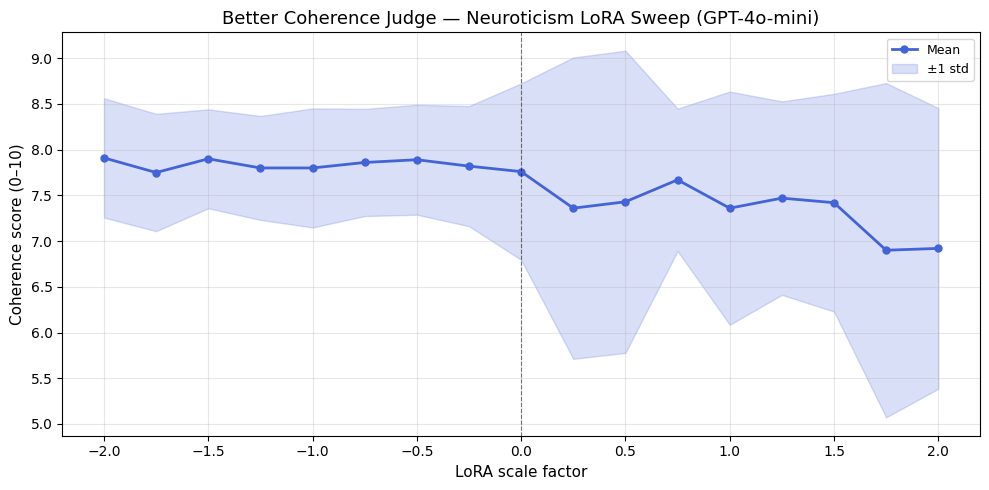

In [5]:
stats = compute_scale_stats(scores_by_scale)
scales = sorted(stats)
means = [stats[s]["mean"] for s in scales]
stds = [stats[s]["std"] for s in scales]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(scales, means, marker="o", linewidth=2, markersize=5, color="#4363d8", label="Mean")
ax.fill_between(scales, [m - s for m, s in zip(means, stds)], [m + s for m, s in zip(means, stds)],
                alpha=0.2, color="#4363d8", label="±1 std")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("LoRA scale factor", fontsize=11)
ax.set_ylabel("Coherence score (0–10)", fontsize=11)
ax.set_title(f"Better Coherence Judge — Neuroticism LoRA Sweep (GPT-4o-mini)", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot: Score Distribution per Scale

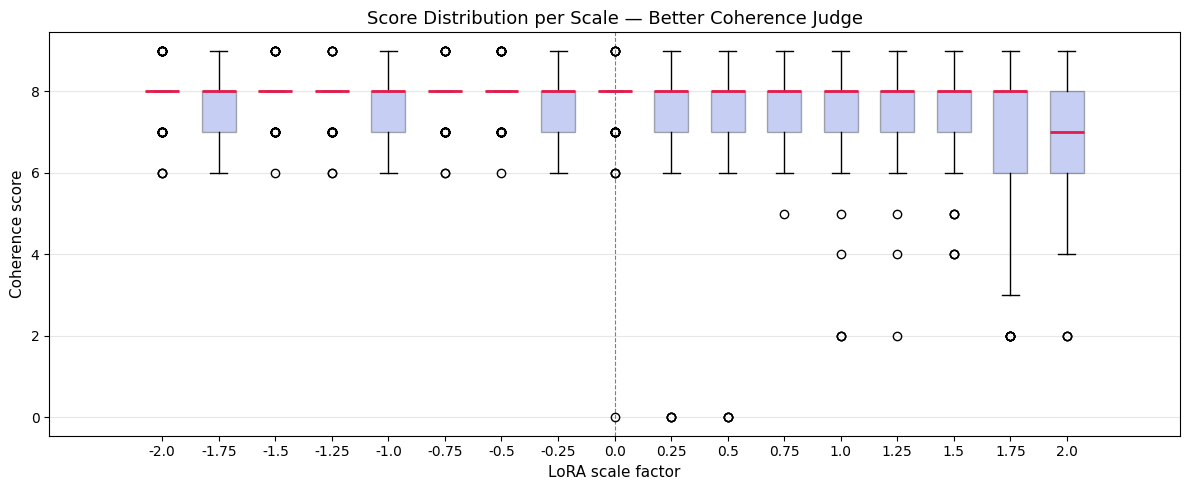

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

positions = sorted(scores_by_scale)
data = [scores_by_scale[s] for s in positions]
bp = ax.boxplot(data, positions=positions, widths=0.15, patch_artist=True,
                boxprops=dict(facecolor="#4363d8", alpha=0.3),
                medianprops=dict(color="#e6194b", linewidth=2))

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("LoRA scale factor", fontsize=11)
ax.set_ylabel("Coherence score", fontsize=11)
ax.set_title("Score Distribution per Scale — Better Coherence Judge", fontsize=13)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## Summary Statistics

In [7]:
stats = compute_scale_stats(scores_by_scale)
sorted_scales = sorted(stats)
all_means = [stats[s]["mean"] for s in sorted_scales]
mono = _monotonicity(all_means)

print(f"Monotonicity (non-decreasing): {mono:.0%}")
print(f"Score @ -2.0: {stats.get(-2.0, {}).get('mean', float('nan')):.3f}")
print(f"Score @  0.0: {stats.get(0.0, {}).get('mean', float('nan')):.3f}")
print(f"Score @ +2.0: {stats.get(2.0, {}).get('mean', float('nan')):.3f}")
print()

print(f"{'Scale':>8s}  {'N':>4s}  {'Mean':>6s}  {'Median':>6s}  {'Std':>5s}")
print("-" * 38)
for scale in sorted_scales:
    s = stats[scale]
    print(f"{scale:+8.2f}  {s['n']:4d}  {s['mean']:6.3f}  {s['median']:6.1f}  {s['std']:5.3f}")

Monotonicity (non-decreasing): 50%
Score @ -2.0: 7.910
Score @  0.0: 7.760
Score @ +2.0: 6.920

   Scale     N    Mean  Median    Std
--------------------------------------
   -2.00   100   7.910     8.0  0.653
   -1.75   100   7.750     8.0  0.642
   -1.50   100   7.900     8.0  0.541
   -1.25   100   7.800     8.0  0.569
   -1.00   100   7.800     8.0  0.651
   -0.75   100   7.860     8.0  0.586
   -0.50   100   7.890     8.0  0.601
   -0.25   100   7.820     8.0  0.657
   +0.00   100   7.760     8.0  0.965
   +0.25   100   7.360     8.0  1.649
   +0.50   100   7.430     8.0  1.653
   +0.75   100   7.670     8.0  0.779
   +1.00   100   7.360     8.0  1.275
   +1.25   100   7.470     8.0  1.058
   +1.50   100   7.420     8.0  1.191
   +1.75   100   6.900     8.0  1.829
   +2.00   100   6.920     7.0  1.535
